# Wavefield · Irregular free-surface topography

SWEEP solves the free-surface topography problem with **three distinct
discretisation families**, all driven through the propagator's
``topography=`` keyword.  When ``topography`` is given a free surface is
implicit; *which* scheme runs is chosen by the equation class plus an
optional ``topo_method=`` switch:

| Family | Equation | How to select | Reference |
|---|---|---|---|
| **Image / staircase** | `Acoustic` | `topography=` (only option) | Mittet 2002 |
| **Image (stress mirror)** | `Elastic` | `topography=`, `topo_method='image'` | Robertsson 1996 |
| **APM** (parameter-modified) | `Elastic` / `ElasticAPM` | `topography=` (default `'apm'`) | Cao & Chen 2018 |
| **Curvilinear** (boundary-fitted) | `AcousticCurvilinear` / `ElasticCurvilinear` | dedicated class + `topography=` | — |

So **acoustic supports 2 methods** (image, curvilinear) and **elastic
supports 3** (image, APM, curvilinear).  This notebook runs them all on
one Gaussian-hill model and compares **wavefields and shot records**,
grouped by physics:

* **Acoustic group** — image vs. curvilinear, compared on *pressure*.
* **Elastic group** — image vs. APM vs. curvilinear, compared on *|v|*.

!!! note "Curvilinear coordinates"
    The image and APM methods work on the **physical grid**: the surface
    is a staircase of row indices and sources/receivers carry their true
    depth.  The curvilinear method instead maps the irregular surface onto
    the **flat top row η = 0 of a boundary-fitted (ξ, η) grid** — so its
    sources/receivers are placed relative to that flat surface, and its
    output wavefield is resampled back to physical (X, Z) for display.
    Curvilinear runs on the eager backend only (`impl='eager'`).

``topography=`` takes a 1-D ``int`` array of surface row indices per
column (the common case); non-single-valued geometries (overhangs,
caves) can be expressed as a 2-D ``float`` air mask and the rest of the
API is identical.

## 1. Build the model

A 96 × 128 grid, ``dh=10 m``. A single Gaussian hill, peak ~5 cells
high above a flat baseline at row 12 of the physical grid.  We set up
**two** equivalent source/receiver layouts: physical-grid coordinates
(`sources` / `receivers`, used by image + APM) and computational-grid
coordinates (`sources_comp` / `receivers_comp`, used by curvilinear),
plus a `resample_curv_to_phys` helper to bring curvilinear wavefields
back to physical (X, Z) for the comparison.

device: cuda


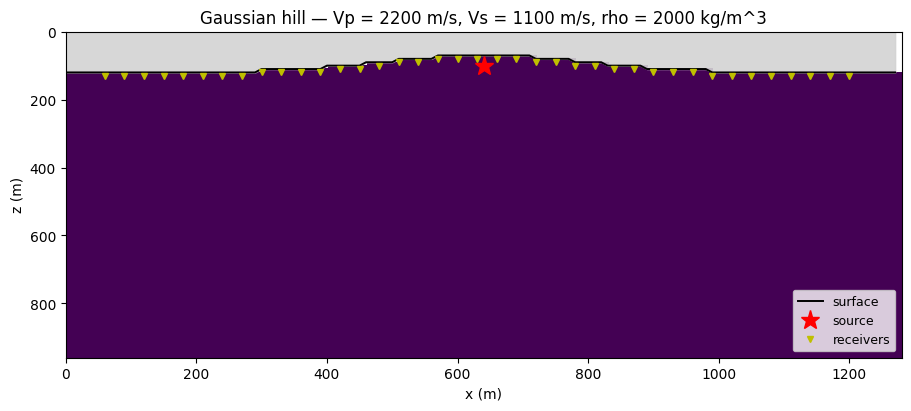

topo_row range: rows 7..12 (depths 70..120 m)
air cells (rows above surface): 1339 of 12288


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from sweep.equations import (
    Acoustic, Elastic, ElasticAPM,          # ElasticAPM is an alias of Elastic
    AcousticCurvilinear, ElasticCurvilinear,  # boundary-fitted (eager-only)
)
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# Grid
NZ, NX = 96, 128
DH     = 10.0
DT     = 1.0e-3
NT     = 700
ABCN   = 30
SO     = 4
FREQ, DELAY = 12.0, 0.12

# Bulk models — homogeneous half-space
VP, VS, RHO = 2200.0, 1100.0, 2000.0
vp  = torch.full((NZ, NX), VP).to(device)
vs  = torch.full((NZ, NX), VS).to(device)
rho = torch.full((NZ, NX), RHO).to(device)

# Topography — single Gaussian hill
x = np.arange(NX, dtype=np.float32)
hill_h0   = 5.0
hill_x0   = NX / 2
hill_sig  = 16.0
hill_base = 12.0
topo_row  = (hill_base - hill_h0 * np.exp(-((x - hill_x0) ** 2) / (2.0 * hill_sig ** 2))).round().astype(np.int64)

# --- Physical-grid geometry (image + APM methods) -------------------------
# Source 3 cells below the local surface, receivers 1 cell below it; the
# z-index is the TRUE physical row, so it tracks the hill.
src_x = NX // 2
src_z = int(topo_row[src_x]) + 3
sources = torch.from_numpy(np.array([[src_x, src_z]], dtype=np.int64)).to(device)
rec_x = np.arange(6, NX - 6, 3, dtype=np.int64)
rec_z = (topo_row[rec_x] + 1).astype(np.int64)
receivers = torch.from_numpy(np.stack([rec_x, rec_z], axis=-1)[None, ...]).to(device)

# --- Computational-grid geometry (curvilinear method) ---------------------
# The boundary-fitted grid maps the surface onto the FLAT row eta=0 for
# every column, so "3 cells below the surface" is simply z-index = 3 and
# "1 cell below" is z-index = 1 — the same physical placement, expressed
# in (xi, eta) coordinates.
DEPTH_SRC, DEPTH_REC = 3, 1
sources_comp = torch.from_numpy(
    np.array([[src_x, DEPTH_SRC]], dtype=np.int64)).to(device)
rec_z_comp = np.full_like(rec_x, DEPTH_REC)
receivers_comp = torch.from_numpy(
    np.stack([rec_x, rec_z_comp], axis=-1)[None, ...]).to(device)

# Ricker wavelet
t = np.arange(NT, dtype=np.float32) * DT - DELAY
wavelet = torch.tensor((1.0e3 * ricker(t, f=FREQ)).astype(np.float32)).to(device)


def resample_curv_to_phys(frames_comp):
    """Map curvilinear snapshots from computational (xi, eta) coords back to
    physical (X, Z).

    ``frames_comp`` is ``(n_frames, NZ, NX)`` already cropped to the
    physical extent, with the free surface on row 0 for every column. For
    each column the computational eta in [0, 1] (NZ samples) is linearly
    interpolated onto the physical depth rows ``[topo_row[ix] .. NZ-1]`` so
    the hill appears in its true shape, directly comparable with the
    image / APM panels. Cells above the surface stay zero (air)."""
    out = np.zeros_like(frames_comp)
    eta_comp = np.linspace(0.0, 1.0, NZ, dtype=np.float32)
    for ix in range(NX):
        s = int(topo_row[ix])
        depth = NZ - 1 - s
        if depth <= 0:
            continue
        eta_phys = np.linspace(0.0, 1.0, depth + 1, dtype=np.float32)
        for k in range(frames_comp.shape[0]):
            out[k, s:NZ, ix] = np.interp(eta_phys, eta_comp, frames_comp[k, :, ix])
    return out


# QC the model
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.imshow(np.where(np.arange(NZ)[:, None] < topo_row[None, :], np.nan, VP), cmap='viridis',
          extent=[0, NX * DH, NZ * DH, 0], aspect='auto')
ax.plot(np.arange(NX) * DH, topo_row * DH, 'k-', lw=1.4, label='surface')
ax.fill_between(np.arange(NX) * DH, 0, topo_row * DH, color='lightgray', alpha=0.9)
ax.plot(src_x * DH, src_z * DH, 'r*', ms=14, label='source')
ax.plot(rec_x * DH, rec_z * DH, 'yv', ms=4, label='receivers')
ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
ax.set_title('Gaussian hill — Vp = 2200 m/s, Vs = 1100 m/s, rho = 2000 kg/m^3')
ax.legend(loc='lower right', fontsize=9)
plt.show()
print(f'topo_row range: rows {topo_row.min()}..{topo_row.max()} '
      f'(depths {topo_row.min() * DH:.0f}..{topo_row.max() * DH:.0f} m)')
print(f'air cells (rows above surface): {int((np.arange(NZ)[:, None] < topo_row[None, :]).sum())} of {NZ*NX}')

## 2. Acoustic group — image vs. curvilinear

Acoustic free-surface topography supports **two** methods. We run both,
then compare their pressure wavefields and shot gathers below.

### 2a. Acoustic · staircase + vacuum (Mittet 2002)

`Acoustic + topography=topo` uses the **vacuum-cell + per-column
image-method** approach.  The propagator snaps the surface to a row
index per column and zeroes any wavefield above it after each time
step.  ``topo_method='image'`` is the only path for ``Acoustic`` and is
auto-selected when ``topography`` is given.  ``topography=topo_row``
gives the per-column surface row; that's all the propagator needs.

In [2]:
def run_acoustic(topo):
    eq = Acoustic(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX),
                     topography=topo,         # auto -> 'image' for Acoustic
                     abcn=ABCN, dh=DH, dt=DT,
                     use_ckpt=False, impl='eager')
    snap_idx = list(range(0, NT, NT // 28))
    with torch.no_grad():
        rec, snaps = prop(wavelet, sources, receivers, models=[vp],
                          return_wavefield=True, snapshot_times=snap_idx)
    return rec, snaps, snap_idx

rec_ac, snaps_ac, snap_idx_ac = run_acoustic(topo_row)
print('acoustic record shape:', tuple(rec_ac.shape))

acoustic record shape: (1, 700, 39, 1)


### 2b. Acoustic · curvilinear (boundary-fitted grid)

`AcousticCurvilinear` maps the irregular surface onto the **flat top row
η = 0** of a boundary-fitted (ξ, η) grid, so the free surface is
imposed exactly (no staircase).  Selected just by using the dedicated
class with `topography=` — as for every method, that already turns the
free surface on (no `free_surface=True` needed).  Runs on the eager
backend only.  Sources and
receivers are given in **computational** coordinates (`sources_comp` /
`receivers_comp` — the same physical placement, measured from the flat
surface), and the returned wavefield is in (ξ, η) coordinates.

In [3]:
def run_acoustic_curv(topo):
    eq = AcousticCurvilinear(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX),
                     topography=topo,  # implies a free surface (free_surface=True optional)
                     abcn=ABCN, dh=DH, dt=DT,
                     use_ckpt=False, impl='eager',        # eager-only equation
                     eager_options={'use_compile': False})
    snap_idx = list(range(0, NT, NT // 28))
    with torch.no_grad():
        # NOTE: computational-grid source/receivers (flat eta=0 surface)
        rec, snaps = prop(wavelet, sources_comp, receivers_comp, models=[vp],
                          return_wavefield=True, snapshot_times=snap_idx)
    return rec, snaps, snap_idx

rec_ac_curv, snaps_ac_curv, snap_idx_ac_curv = run_acoustic_curv(topo_row)
print('acoustic (curvilinear) record shape:', tuple(rec_ac_curv.shape))

acoustic (curvilinear) record shape: (1, 700, 39, 1)


## 3. Elastic group — image vs. APM vs. curvilinear

Elastic free-surface topography supports **three** methods. We run all
three, then compare their `|v|` wavefields and `vz` shot gathers below.

### 3a. Elastic · per-column image method (Robertsson 1996)

``Elastic + topography=topo + topo_method='image'`` uses the
**odd-parity stress mirror** generalised to a per-column surface row.
After each time step the propagator additionally zeros ``σ_zz`` and
``σ_xz`` at the surface row.  Vacuum cells above the surface are not
zeroed in the wavefield — only the stress mirror enforces the
traction-free BC.

Robertsson is fast and works well for gentle topography; very steep
staircase corners can drive a slow long-time instability.

In [4]:
def run_elastic_image(topo):
    eq = Elastic(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX),
                     topography=topo, topo_method='image',  # explicit Robertsson
                     abcn=ABCN, dh=DH, dt=DT,
                     use_ckpt=False, impl='eager',
                     eager_options={'use_compile': False})
    snap_idx = list(range(0, NT, NT // 28))
    with torch.no_grad():
        rec, snaps = prop(wavelet, sources, receivers, models=[vp, vs, rho],
                          return_wavefield=True, snapshot_times=snap_idx)
    return rec, snaps, snap_idx

rec_el_img, snaps_el_img, snap_idx_el = run_elastic_image(topo_row)
print('elastic (image) record shape:', tuple(rec_el_img.shape),
      '— last channel: 0=vx, 1=vz')
print('|v|max:', rec_el_img.abs().max().item())

elastic (image) record shape: (1, 700, 39, 2) — last channel: 0=vx, 1=vz
|v|max: 0.0023499256931245327


### 3b. Elastic · APM (Cao & Chen 2018)

``Elastic + topography=topo`` (with the default ``topo_method='apm'``)
activates the **Adaptive Parameter-Modified** method.  Instead of
mirroring stresses, the moduli ``(λ, μ)`` and densities
``(ρ_x, ρ_z, μ_xz)`` are modified per surface-cell category
(H / VL / VR / OC / IC) so the standard FD update *automatically*
produces ``σ·n = 0``.  No per-step BC enforcement residual — the
method is stable for arbitrary simulation time even on rough
staircase topography (Cao & Chen 2018 Fig 4).

``ElasticAPM`` is exported as an alias of ``Elastic`` for
discoverability — it documents the intent "this run uses APM" but is
literally the same class.

In [5]:
def run_elastic_apm(topo):
    # ElasticAPM is the same class as Elastic — using the alias here
    # makes the intent obvious to anyone reading the code.
    eq = ElasticAPM(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX),
                     topography=topo,          # auto -> 'apm' for Elastic (default)
                     abcn=ABCN, dh=DH, dt=DT,
                     use_ckpt=False, impl='eager',
                     eager_options={'use_compile': False})
    snap_idx = list(range(0, NT, NT // 28))
    with torch.no_grad():
        rec, snaps = prop(wavelet, sources, receivers, models=[vp, vs, rho],
                          return_wavefield=True, snapshot_times=snap_idx)
    return rec, snaps, snap_idx

rec_el_apm, snaps_el_apm, snap_idx_apm = run_elastic_apm(topo_row)
print('elastic (APM) record shape:', tuple(rec_el_apm.shape))
print('|v|max:', rec_el_apm.abs().max().item())

elastic (APM) record shape: (1, 700, 39, 2)
|v|max: 0.00014159828424453735


### 3c. Elastic · curvilinear (boundary-fitted grid)

`ElasticCurvilinear` applies the chain rule to every ∂/∂X, ∂/∂Z in the
Virieux (1986) velocity–stress system on the boundary-fitted grid, and
enforces `σ_zz = σ_xz = 0` on the **flat η = 0 row** — eliminating the
staircase-corner energy injection that drives the image method's
late-time growth.  Like the acoustic case it is eager-only and takes
computational-grid source/receiver coordinates.

In [6]:
def run_elastic_curv(topo):
    eq = ElasticCurvilinear(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX),
                     topography=topo,  # implies a free surface (free_surface=True optional)
                     abcn=ABCN, dh=DH, dt=DT,
                     use_ckpt=False, impl='eager',        # eager-only equation
                     eager_options={'use_compile': False})
    snap_idx = list(range(0, NT, NT // 28))
    with torch.no_grad():
        # NOTE: computational-grid source/receivers (flat eta=0 surface)
        rec, snaps = prop(wavelet, sources_comp, receivers_comp, models=[vp, vs, rho],
                          return_wavefield=True, snapshot_times=snap_idx)
    return rec, snaps, snap_idx

rec_el_curv, snaps_el_curv, snap_idx_el_curv = run_elastic_curv(topo_row)
print('elastic (curvilinear) record shape:', tuple(rec_el_curv.shape))
print('|v|max:', rec_el_curv.abs().max().item())

elastic (curvilinear) record shape: (1, 700, 39, 2)
|v|max: 0.0001479014754295349


## 4. Wavefield comparison

Running this cell builds a GIF (`15_wavefield_topography.gif`) **next to
the notebook** so the animation works offline / as a standalone asset,
and displays it inline.  Two rows, grouped by physics:

* **Top — Acoustic** *(pressure)*: image · curvilinear
* **Bottom — Elastic** *(|v|)*: image · APM · curvilinear

Below the surface (gray band) the kinematics match across all methods;
the interesting differences are in the **surface behaviour** —
staircase-corner scattering on the image-method paths, traction-free
moduli on APM, and a geometrically exact flat free surface on the
curvilinear paths.  The curvilinear panels are resampled from the
boundary-fitted (ξ, η) grid back to physical (X, Z); each elastic panel
is independently normalised so wavefront *shape* stays visible despite
the very different absolute amplitudes between methods.

Saved animation to: /home/wangs0j/sweep-local/sweep-stack-topo-curv/examples/notebooks/15_wavefield_topography.gif
   size = 3204.4 KB, 28 frames



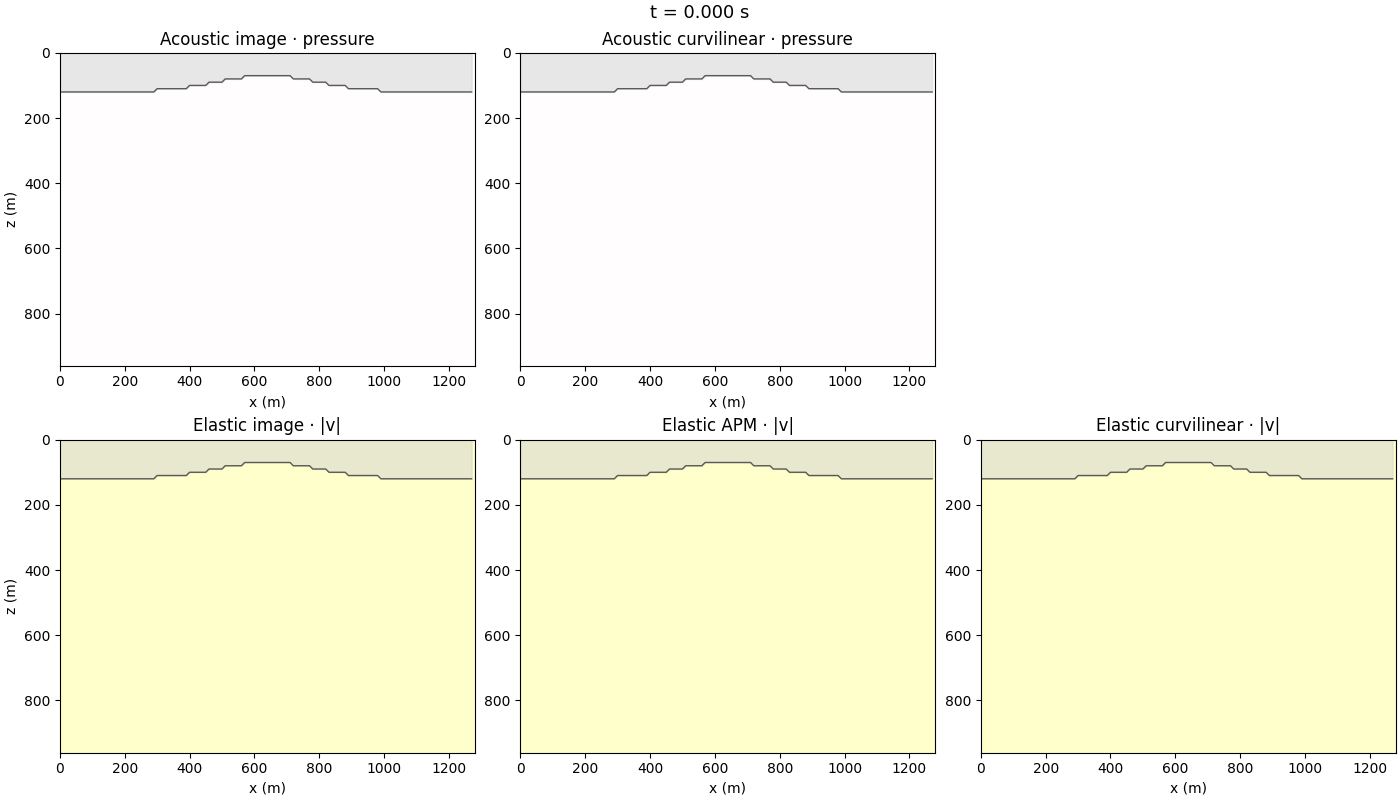

In [7]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from pathlib import Path
from IPython.display import HTML, display

def crop_phys(snap_2d, free_surface):
    """Crop PML padding (top = 0 if free_surface=True, ABCN if =False)."""
    top = 0 if free_surface else ABCN
    return snap_2d[top:top + NZ, ABCN:ABCN + NX]

n_frames = len(snap_idx_ac)

# --- Acoustic (pressure) --------------------------------------------------
p_img  = np.stack([crop_phys(snaps_ac[i, 0, 0, 0].cpu().numpy(), True) for i in range(n_frames)])
p_curv = resample_curv_to_phys(
    np.stack([crop_phys(snaps_ac_curv[i, 0, 0, 0].cpu().numpy(), True) for i in range(n_frames)]))

# --- Elastic (|v|) --------------------------------------------------------
def vmag(snaps, free_surface):
    vx = np.stack([crop_phys(snaps[i, 0, 0, 0].cpu().numpy(), free_surface) for i in range(n_frames)])
    vz = np.stack([crop_phys(snaps[i, 1, 0, 0].cpu().numpy(), free_surface) for i in range(n_frames)])
    return np.sqrt(vx ** 2 + vz ** 2)

vmag_img  = vmag(snaps_el_img, True)     # image method → top PML suppressed
vmag_apm  = vmag(snaps_el_apm, False)    # APM → PML on both top and bottom
vmag_curv = resample_curv_to_phys(vmag(snaps_el_curv, True))

# Acoustic: shared pressure clip (both methods ~same amplitude).
# Elastic: per-panel clip (image grows late, APM/curv are tiny) so the
# wavefront morphology stays visible in every panel.
def clip(a, pct=99.5):
    return float(np.percentile(np.abs(a), pct)) or 1e-12
p_clip = clip(np.concatenate([p_img, p_curv]))
v_clip = [clip(vmag_img), clip(vmag_apm), clip(vmag_curv)]

extent = [0, NX * DH, NZ * DH, 0]
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes[0, 2].axis('off')   # acoustic row has only 2 panels

ims = []
# Row 0 — acoustic pressure
ac_panels = [(axes[0, 0], p_img, 'Acoustic image · pressure'),
             (axes[0, 1], p_curv, 'Acoustic curvilinear · pressure')]
for ax, data, title in ac_panels:
    im = ax.imshow(data[0], cmap='seismic',
                   norm=TwoSlopeNorm(vmin=-p_clip, vcenter=0, vmax=p_clip),
                   extent=extent, aspect='auto')
    ax.set_title(title); ims.append((im, data))
# Row 1 — elastic |v|
el_panels = [(axes[1, 0], vmag_img, 'Elastic image · |v|', v_clip[0]),
             (axes[1, 1], vmag_apm, 'Elastic APM · |v|', v_clip[1]),
             (axes[1, 2], vmag_curv, 'Elastic curvilinear · |v|', v_clip[2])]
for ax, data, title, c in el_panels:
    im = ax.imshow(data[0], cmap='YlOrRd', vmin=0, vmax=c, extent=extent, aspect='auto')
    ax.set_title(title); ims.append((im, data))

for ax in (axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1], axes[1, 2]):
    ax.plot(np.arange(NX) * DH, topo_row * DH, 'k-', lw=1.0, alpha=0.6)
    ax.fill_between(np.arange(NX) * DH, 0, topo_row * DH, color='lightgray', alpha=0.5)
    ax.set_xlabel('x (m)')
axes[0, 0].set_ylabel('z (m)'); axes[1, 0].set_ylabel('z (m)')
title_obj = fig.suptitle(f't = {snap_idx_ac[0] * DT:.3f} s', fontsize=13)

def update(i):
    for im, data in ims:
        im.set_data(data[i])
    title_obj.set_text(f't = {snap_idx_ac[i] * DT:.3f} s')
    return [im for im, _ in ims] + [title_obj]

anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=120, blit=False)

gif_path = Path('15_wavefield_topography.gif')
anim.save(gif_path, writer=PillowWriter(fps=8))
plt.close(fig)
import base64
gif_b64 = base64.b64encode(gif_path.read_bytes()).decode('ascii')
print(f'Saved animation to: {gif_path.resolve()}')
print(f'   size = {gif_path.stat().st_size / 1024:.1f} KB, {n_frames} frames')
# Use a raw <img> tag so the GIF renders consistently in Jupyter,
# VSCode, mkdocs-jupyter, and nbviewer — Image() emits a text/plain
# fallback which some renderers prefer over image/gif.
display(HTML(f'<img src="data:image/gif;base64,{gif_b64}" '
             f'alt="topography wavefield animation" '
             f'style="max-width:100%;height:auto;" />'))

## 5. Shot-gather comparison

All methods share the same source / receiver geometry on the irregular
surface (image/APM on the physical grid, curvilinear on the flat
computational surface — the same physical placement).  The hyperbolic
direct wave + free-surface multiples should align in **time** across
methods; differences in amplitude and surface-wave character reflect how
each scheme imposes the traction-free BC.  Same grouping as the
wavefields:

* **Top — Acoustic** *(pressure)*: image · curvilinear
* **Bottom — Elastic** *(vz)*: image · APM · curvilinear

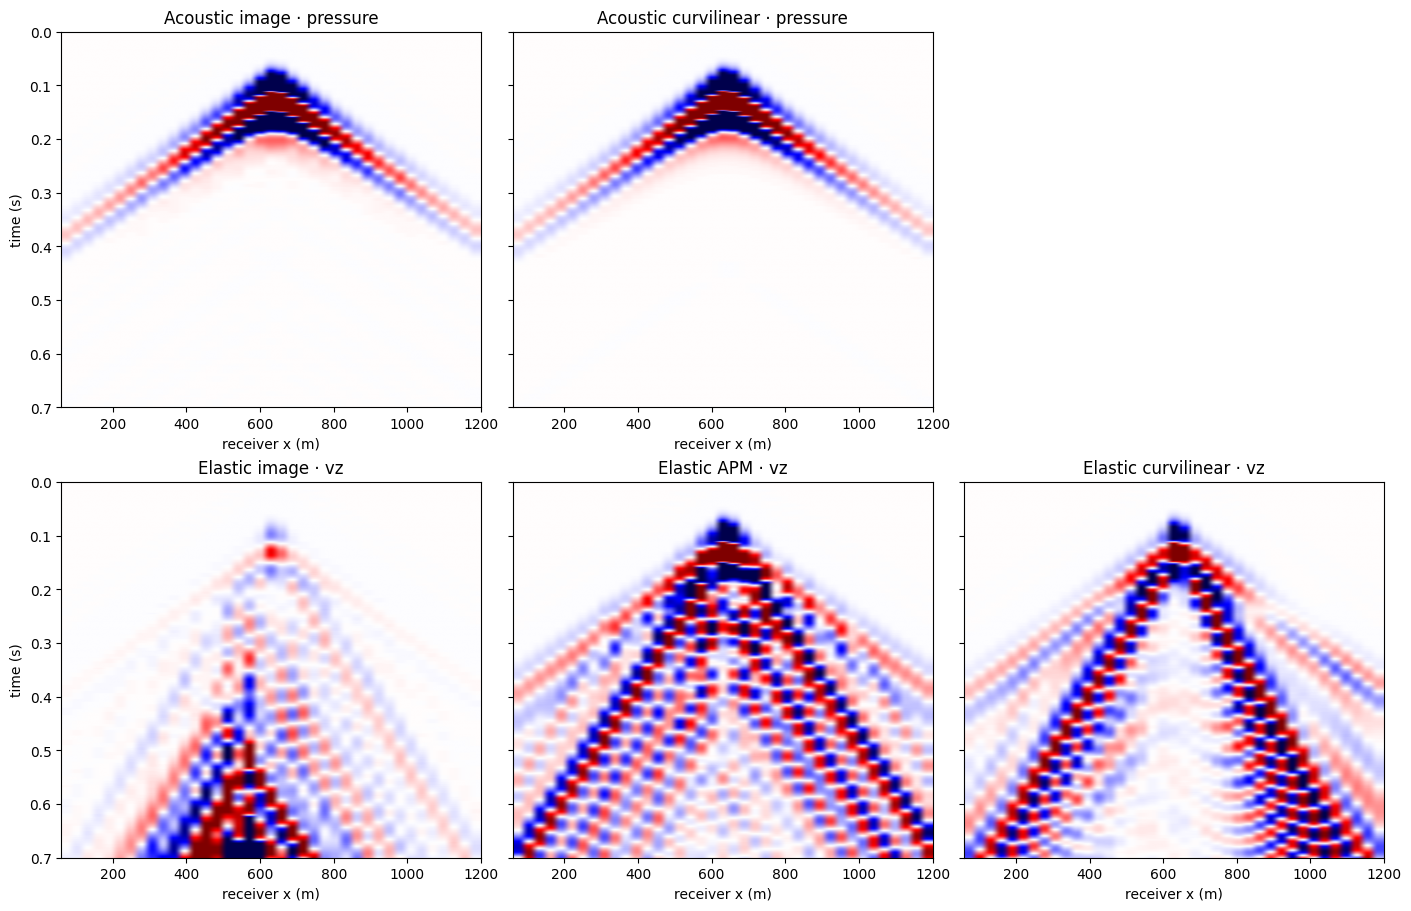

In [8]:
def trace_clip(rec_np, pct=98.0):
    return max(float(np.percentile(np.abs(rec_np), pct)), 1e-12)

extent_g = [rec_x.min() * DH, rec_x.max() * DH, NT * DT, 0]

# Acoustic pressure gathers
p_ac_im   = np.squeeze(rec_ac.cpu().numpy())        # (nt, nrec)
p_ac_cv   = np.squeeze(rec_ac_curv.cpu().numpy())
# Elastic vz gathers
vz_el_im  = rec_el_img[0, :, :, 1].cpu().numpy()
vz_el_ap  = rec_el_apm[0, :, :, 1].cpu().numpy()
vz_el_cv  = rec_el_curv[0, :, :, 1].cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True, sharey=True)
axes[0, 2].axis('off')   # acoustic row has only 2 panels

panels = [
    (axes[0, 0], p_ac_im, 'Acoustic image · pressure'),
    (axes[0, 1], p_ac_cv, 'Acoustic curvilinear · pressure'),
    (axes[1, 0], vz_el_im, 'Elastic image · vz'),
    (axes[1, 1], vz_el_ap, 'Elastic APM · vz'),
    (axes[1, 2], vz_el_cv, 'Elastic curvilinear · vz'),
]
for ax, panel, title in panels:
    clip = trace_clip(panel)
    ax.imshow(panel, cmap='seismic',
              norm=TwoSlopeNorm(vmin=-clip, vcenter=0, vmax=clip),
              extent=extent_g, aspect='auto')
    ax.set_title(title); ax.set_xlabel('receiver x (m)')
axes[0, 0].set_ylabel('time (s)'); axes[1, 0].set_ylabel('time (s)')
plt.show()

## Summary · API cheatsheet

```python
from sweep.equations import (
    Acoustic, Elastic, ElasticAPM,            # ElasticAPM is Elastic
    AcousticCurvilinear, ElasticCurvilinear,  # boundary-fitted, eager-only
)
from sweep.propagator.torch import PropTorch

# `topo` is the surface row per physical column — shape (nx,), int.
# For overhangs / caves, pass a 2-D `(nz, nx)` air mask (>0.5 = air);
# the propagator converts internally and the rest of the API is identical.

# --- Acoustic (2 methods) ------------------------------------------------
# image / staircase + vacuum (Mittet 2002) — only physical-grid method
PropTorch(Acoustic(...), topography=topo, ...)
# curvilinear — boundary-fitted grid; src/rec on the flat eta=0 surface
PropTorch(AcousticCurvilinear(...), topography=topo, impl='eager', ...)

# --- Elastic (3 methods) -------------------------------------------------
# APM (Cao & Chen 2018), the default — best long-time stability
PropTorch(Elastic(...), topography=topo, ...)
# Robertsson image method (explicit opt-in)
PropTorch(Elastic(...), topography=topo, topo_method='image', ...)
# curvilinear — boundary-fitted grid
PropTorch(ElasticCurvilinear(...), topography=topo, impl='eager', ...)
```

Pass `models=[vp]` for the acoustic equations and `models=[vp, vs, rho]`
for the elastic equations.  **Geometry note:** image/APM take physical
source/receiver rows (tracking the hill); curvilinear takes them
relative to the flat computational surface (`z=0` at the surface).  Its
output wavefield lives in (ξ, η) coordinates and is resampled back to
(X, Z) for display — see `resample_curv_to_phys` above.

**On `free_surface`:** passing `topography=` already turns the free
surface on for *every* method (image, APM, curvilinear) — the propagator
infers it, so `free_surface=True` is optional there.  You only need
`free_surface=True` explicitly for a **flat** free surface with no
topography, e.g. `PropTorch(Acoustic(...), free_surface=True, ...)`.

---

<p><strong>Download this notebook</strong> &mdash; <a href="15_wavefield_topography.ipynb" download><code>15_wavefield_topography.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/docs/notebooks/15_wavefield_topography.ipynb">view on GitHub</a></p>